In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports + Paths

In [6]:
import os
import random
import shutil
import numpy as np
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance
import cv2

BASE_DIR = Path("/content/drive/MyDrive/genai_project")
INPUT_DIR = BASE_DIR / "data" / "synthetic_clean"
OUTPUT_DIR = BASE_DIR / "data" / "synthetic_degraded"

CLASSES = ["clean", "finished", "full"]

def reset_degraded_folder():
    if OUTPUT_DIR.exists():
        print("Deleting existing degraded folder...")
        shutil.rmtree(OUTPUT_DIR)

    for cls in CLASSES:
        os.makedirs(OUTPUT_DIR / cls, exist_ok=True)

    print("Fresh degraded folder ready:", OUTPUT_DIR)

# reset_degraded_folder()

degradation function

In [3]:
import random
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import cv2

# -----------------------
# BLUR
# -----------------------
def add_blur(img, radius_range=(0.3, 1.0)):
    radius = random.uniform(*radius_range)
    return img.filter(ImageFilter.GaussianBlur(radius))


# -----------------------
# NOISE (עדין יותר!)
# -----------------------
def add_noise(img, std_range=(10, 20)):
    arr = np.array(img).astype(np.float32)

    std = random.uniform(*std_range)
    noise = np.random.normal(0, std, arr.shape)

    arr += noise
    arr = np.clip(arr, 0, 255).astype(np.uint8)

    return Image.fromarray(arr)


# -----------------------
# LIGHTING
# -----------------------
def change_lighting(img, brightness_range=(0.5, 1.6), contrast_range=(0.5, 1.6)):
    img = ImageEnhance.Brightness(img).enhance(random.uniform(*brightness_range))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(*contrast_range))
    return img


# -----------------------
# DOWNSCALE
# -----------------------
def downscale(img):
    size = random.choice([96, 128, 160, 192])
    small = img.resize((size, size), Image.BILINEAR)
    return small.resize((224, 224), Image.BILINEAR)

# -----------------------
# JPEG COMPRESSION
# -----------------------
def compress(img, quality_range=(10, 50)):
    quality = random.randint(*quality_range)

    temp_path = "temp.jpg"
    img.save(temp_path, quality=quality)

    return Image.open(temp_path)


# -----------------------
# COLOR SHIFT
# -----------------------
def color_shift(img, shift_range=(0.7, 1.3)):
    arr = np.array(img).astype(np.float32)

    arr[:, :, 0] *= random.uniform(*shift_range)
    arr[:, :, 1] *= random.uniform(*shift_range)
    arr[:, :, 2] *= random.uniform(*shift_range)

    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


# -----------------------
# ROTATION
# -----------------------
# rotate - top view only
def rotate_image(img):
    angle = random.choice([0, 90, 180, 270])
    return img.rotate(angle, expand=True)

def slight_rotate(img, angle_range=(-20, 20)):
    angle = random.uniform(*angle_range)
    return img.rotate(angle, resample=Image.BILINEAR, fillcolor=(0,0,0))

# -----------------------
# PERSPECTIVE
# -----------------------
def perspective_transform(img, scale_range=(0.05, 0.15)):
    width, height = img.size

    scale = random.uniform(*scale_range)
    shift = scale * width

    src = np.float32([
        [0, 0],
        [width, 0],
        [width, height],
        [0, height]
    ])

    dst = np.float32([
        [random.uniform(0, shift), random.uniform(0, shift)],
        [width - random.uniform(0, shift), random.uniform(0, shift)],
        [width - random.uniform(0, shift), height - random.uniform(0, shift)],
        [random.uniform(0, shift), height - random.uniform(0, shift)]
    ])

    matrix = cv2.getPerspectiveTransform(src, dst)

    warped = cv2.warpPerspective(
        np.array(img),
        matrix,
        (width, height),
        borderMode=cv2.BORDER_REFLECT
    )

    return Image.fromarray(warped)

Degrade function

In [4]:
def degrade_image(img, cls):

    severity = random.random()

    img = downscale(img)

    # Geometry
    if random.random() < 0.7:
        img = slight_rotate(img, (-10, 10) if severity < 0.5 else (-25, 25))

    if random.random() < 0.7:
        img = rotate_image(img)

    if random.random() < 0.6:
        img = perspective_transform(img, (0.05, 0.12) if severity < 0.5 else (0.12, 0.25))

    # Blur
    if random.random() < 0.6:
        img = add_blur(img, (0.3, 1.0) if severity < 0.5 else (1.0, 2.5))

    # Noise
    if random.random() < 0.7:
        if cls == "clean":
            img = add_noise(img, (2, 8))
        else:
            img = add_noise(img, (5, 15))

    # Lighting
    if random.random() < 0.6:
        img = change_lighting(img, (0.7, 1.4), (0.7, 1.4))

    # Color
    if random.random() < 0.5:
        img = color_shift(img, (0.85, 1.15))

    # Compression
    if random.random() < 0.5:
        img = compress(img, (30, 70))

    return img

Generate dataset

In [5]:
from tqdm import tqdm

def generate_augmented_dataset():

    for cls in CLASSES:

        class_input = INPUT_DIR / cls
        class_output = OUTPUT_DIR / cls

        images = list(class_input.glob("*"))

        print(f"\nProcessing {cls} ({len(images)} images)")

        for img_path in tqdm(images):

            img = Image.open(img_path).convert("RGB")

            base_name = img_path.stem

            # how much augs per imape - random choise
            num_aug = random.choice([2, 3, 4, 5])

            for i in range(num_aug):

                random.seed(np.random.randint(0, 100000))

                img_aug = degrade_image(img.copy(), cls)

                img_aug.save(class_output / f"{base_name}_aug{i}.jpg")

generate_augmented_dataset()
print("\nDONE generating augmented dataset")

for cls in CLASSES:
    print(cls, len(list((OUTPUT_DIR / cls).glob("*"))))


Processing clean (535 images)


100%|██████████| 535/535 [01:12<00:00,  7.41it/s]



Processing finished (641 images)


100%|██████████| 641/641 [01:31<00:00,  7.03it/s]



Processing full (774 images)


100%|██████████| 774/774 [01:49<00:00,  7.09it/s]


DONE generating augmented dataset 🚀
clean 1888
finished 2254
full 2684


In [5]:
# 🔥 BLOCK: UPSAMPLE TO MAX (השלמה לפי הגדול)

def upsample_augmented_dataset():

    # שלב 1: למדוד גדלים
    sizes = {
        cls: len(list((OUTPUT_DIR / cls).glob("*")))
        for cls in CLASSES
    }

    max_size = max(sizes.values())

    print("Before:", sizes)
    print("Target size:", max_size)

    # שלב 2: להשלים כל קלאס קטן
    for cls in CLASSES:

        class_dir = OUTPUT_DIR / cls
        class_files = list(class_dir.glob("*"))

        current_size = len(class_files)

        if current_size >= max_size:
            continue

        print(f"Upsampling {cls} from {current_size} → {max_size}")

        idx = 0

        while len(class_files) < max_size:

            # בוחרים תמונה קיימת
            img_path = random.choice(class_files)
            img = Image.open(img_path).convert("RGB")

            # יוצרים augmentation חדש
            img_aug = degrade_image(img, cls)

            # שם חדש שלא יתנגש
            new_name = f"{img_path.stem}_extra{idx}.jpg"
            new_path = class_dir / new_name

            img_aug.save(new_path)

            class_files.append(new_path)
            idx += 1

    # בדיקה
    sizes_after = {
        cls: len(list((OUTPUT_DIR / cls).glob("*")))
        for cls in CLASSES
    }

    print("After:", sizes_after)

upsample_augmented_dataset()

Before: {'clean': 1888, 'finished': 2254, 'full': 2673}
Target size: 2673
Upsampling clean from 1888 → 2673
Upsampling finished from 2254 → 2673
After: {'clean': 2673, 'finished': 2673, 'full': 2673}


visual checking

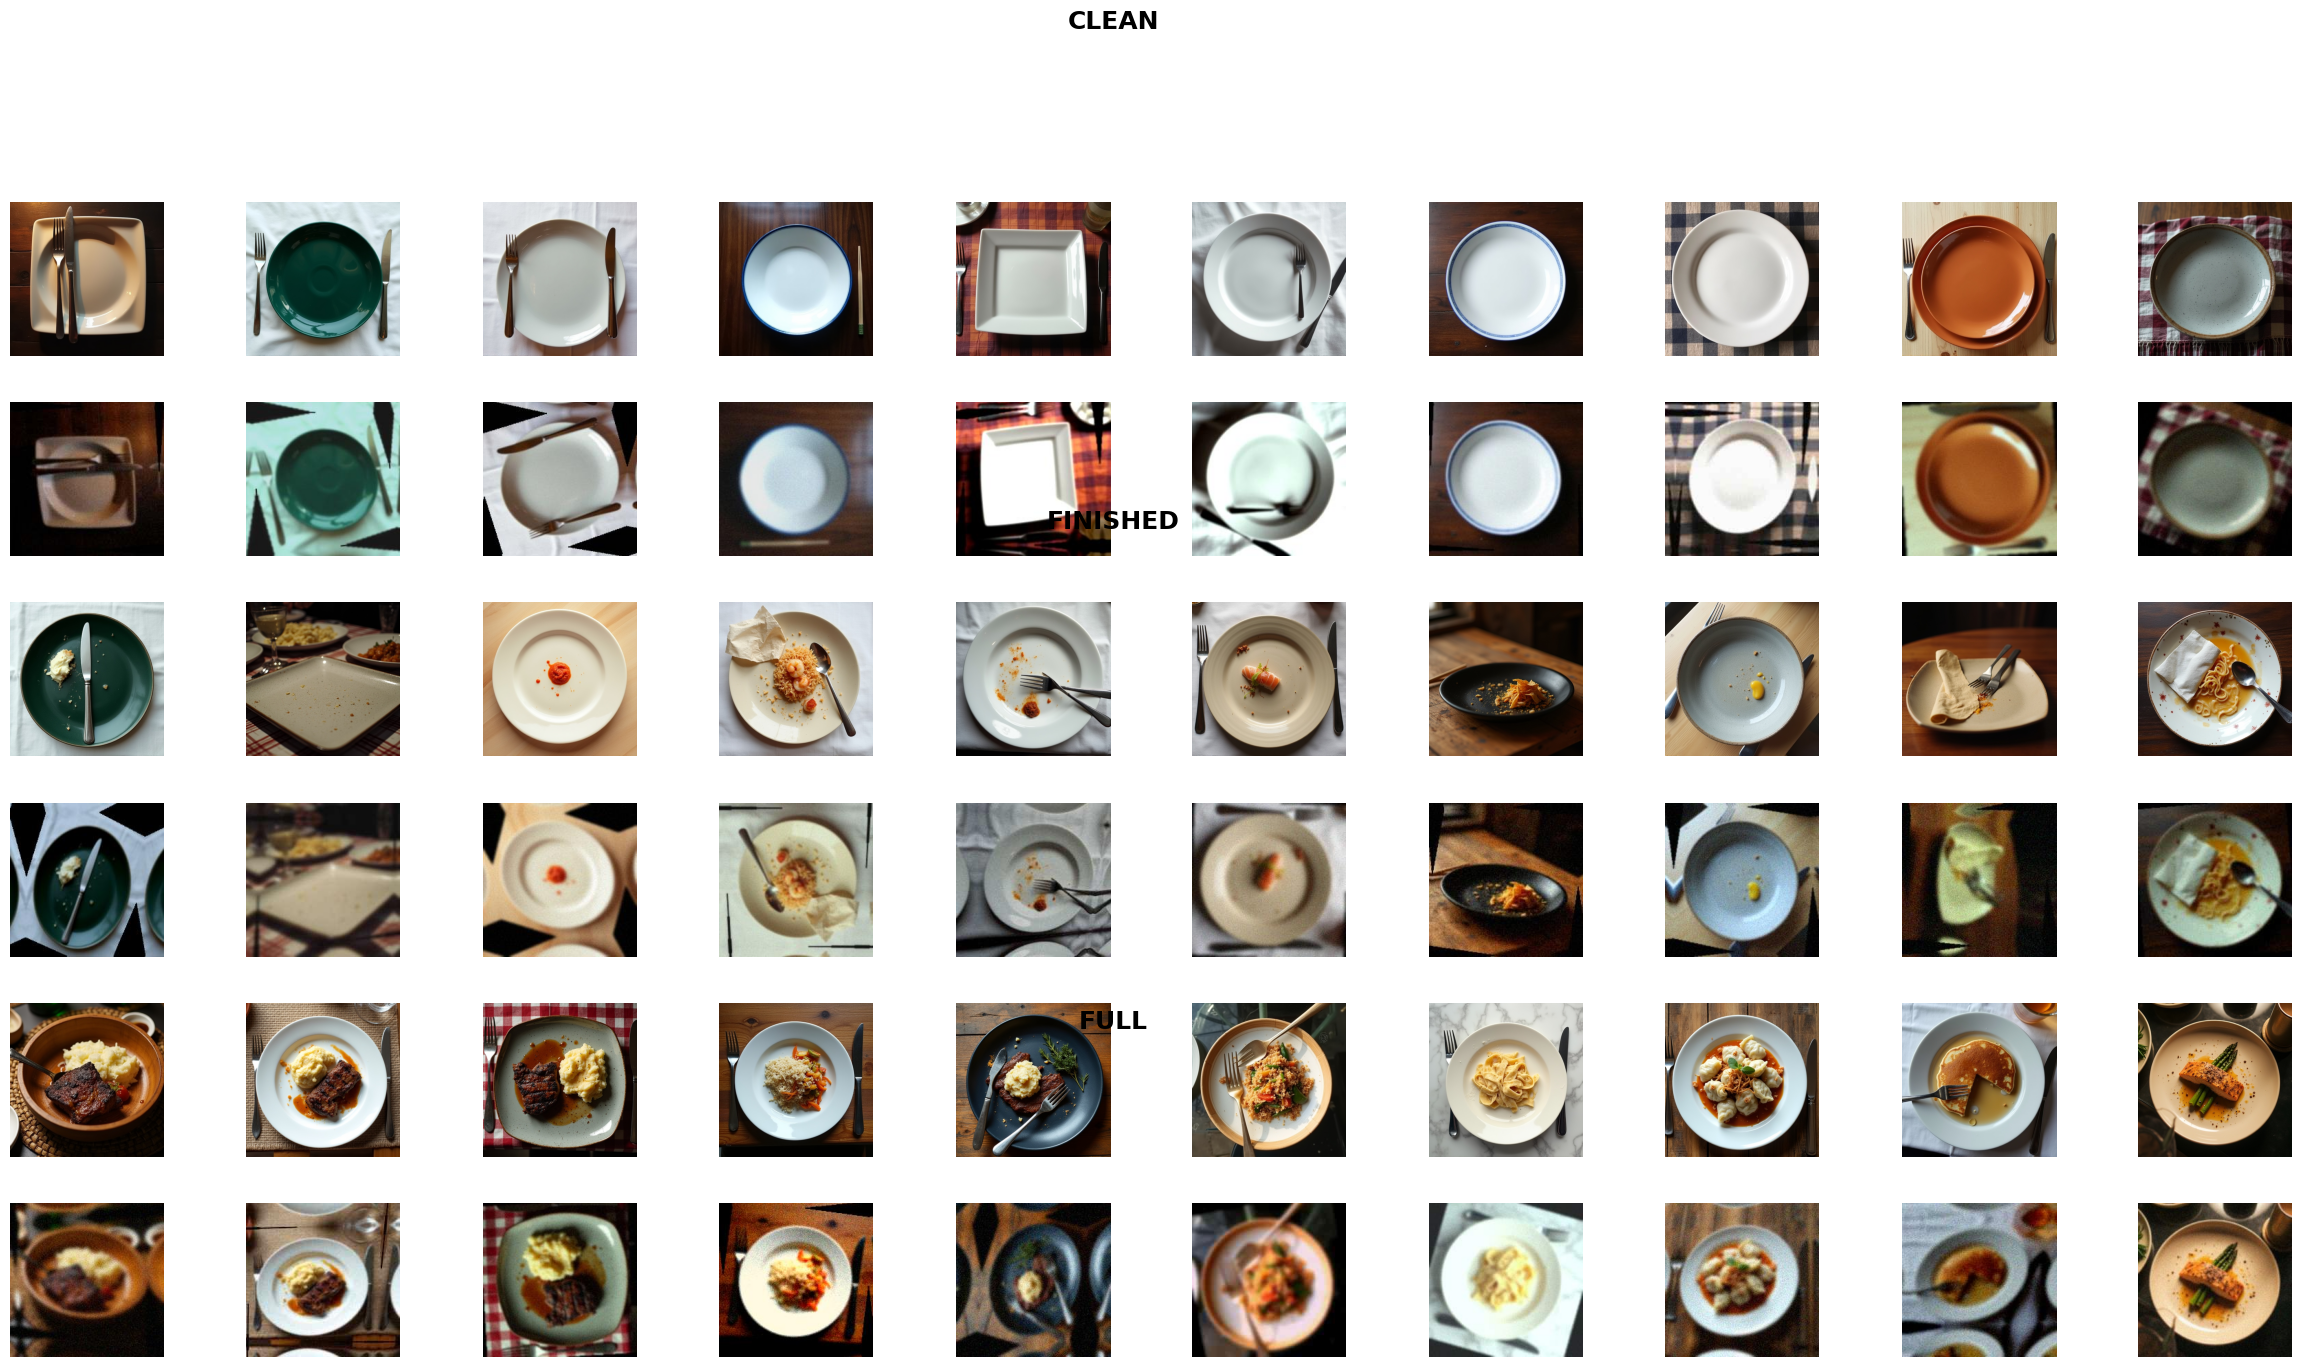

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
from datetime import datetime

def show_all_classes(classes):

    num_classes = len(classes)
    num_images = 10

    fig, axes = plt.subplots(
        2 * num_classes,
        num_images,
        figsize=(3 * num_images, 2.5 * 2 * num_classes)
    )

    for c_idx, cls in enumerate(classes):

        clean_files = list((INPUT_DIR / cls).glob("*"))[:num_images]

        for i, clean_path in enumerate(clean_files):

            img = Image.open(clean_path)

            # --- BASE ---
            axes[2*c_idx, i].imshow(img)
            axes[2*c_idx, i].axis("off")

            # --- MATCH AUG ---
            base_name = clean_path.stem
            aug_candidates = list((OUTPUT_DIR / cls).glob(f"{base_name}_aug*.jpg"))

            if len(aug_candidates) > 0:
                aug_path = random.choice(aug_candidates)
                aug_img = Image.open(aug_path)
            else:
                aug_img = img  # fallback

            # --- DEGRADED ---
            axes[2*c_idx + 1, i].imshow(aug_img)
            axes[2*c_idx + 1, i].axis("off")

        fig.text(
            0.5,
            1 - (c_idx / num_classes),
            cls.upper(),
            ha='center',
            va='center',
            fontsize=18,
            fontweight='bold'
        )

    plt.subplots_adjust(hspace=0.3)

    save_dir = "/content/drive/MyDrive/genai_project/plots"
    os.makedirs(save_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    plt.savefig(f"{save_dir}/all_classes_aug_{timestamp}.png", bbox_inches="tight", dpi=300)
    plt.show()


show_all_classes(["clean", "finished", "full"])